In [1]:
# ============================================================
# 04b_error_analysis.ipynb
# Error Analysis
# Breast Tumor Classification Project
# ============================================================

In [2]:
# ============================================================
# 1. Import Libraries
# ============================================================

import sys
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

In [3]:
# ============================================================
# 2. Import Custom Modules
# ============================================================

from src.config import (
    PROCESSED_DATA_FILE,
    MODEL_FILE
)

from src.split import stratified_split

from src.train import generate_predictions

from src.thresholding import apply_threshold

from src.error_analysis import (
    get_false_positives,
    get_false_negatives
)


In [4]:
# ============================================================
# 3. Load Dataset
# ============================================================

df = pd.read_csv(
    PROCESSED_DATA_FILE
)

In [5]:
# ============================================================
# 4. Split Features and Target
# ============================================================

X = df.drop(columns=['Diagnosis'])

y = df['Diagnosis']


In [6]:
# ============================================================
# 5. Train-Test Split
# ============================================================

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = stratified_split(X, y)

In [7]:
# ============================================================
# 6. Load Trained Model
# ============================================================

model = joblib.load(MODEL_FILE)

In [8]:
# ============================================================
# 7. Generate Probabilities
# ============================================================

predictions, probabilities = generate_predictions(
    model,
    X_test
)

In [9]:
# ============================================================
# 8. Apply Custom Threshold
# ============================================================

custom_threshold = 0.40

threshold_predictions = apply_threshold(
    probabilities,
    threshold=custom_threshold
)

In [10]:
# ============================================================
# 9. False Positives
# ============================================================

false_positives = get_false_positives(
    X_test,
    y_test,
    threshold_predictions,
    probabilities
)

print("False Positives:")

print(false_positives.shape[0])

false_positives.head()

False Positives:
0


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,actual,predicted,probability


In [11]:
# ============================================================
# 10. False Negatives
# ============================================================

false_negatives = get_false_negatives(
    X_test,
    y_test,
    threshold_predictions,
    probabilities
)

print("False Negatives:")

print(false_negatives.shape[0])

false_negatives.head()

False Negatives:
1


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,actual,predicted,probability
86,14.48,21.46,94.25,648.2,0.09444,0.09947,0.1204,0.04938,0.2075,0.05636,...,808.9,0.1306,0.1976,0.3349,0.1225,0.302,0.06846,1,0,0.3


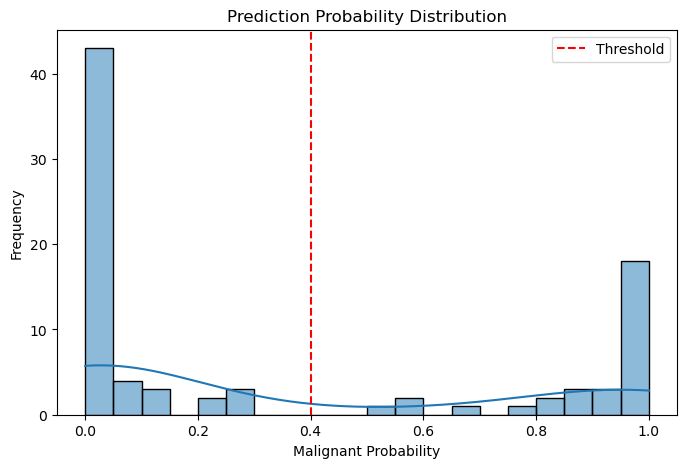

In [12]:
# ============================================================
# 11. Probability Distribution
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    probabilities,
    bins=20,
    kde=True
)

plt.axvline(
    custom_threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Malignant Probability")

plt.ylabel("Frequency")

plt.legend()

plt.show()

In [13]:
# ============================================================
# 12. Hard Cases Analysis
# ============================================================

hard_cases = pd.DataFrame({
    'actual': y_test,
    'probability': probabilities
})

hard_cases['distance_from_threshold'] = (
    abs(
        hard_cases['probability'] -
        custom_threshold
    )
)

hard_cases = hard_cases.sort_values(
    by='distance_from_threshold'
)

hard_cases.head(10)

,actual,probability,distance_from_threshold
86,1,0.300,0.100
469,0,0.280,0.120
39,1,0.545,0.145
347,0,0.255,0.145
505,0,0.245,0.155
99,1,0.560,0.160
275,0,0.230,0.170
205,1,0.590,0.190
171,1,0.695,0.295
554,0,0.105,0.295


In [14]:
# ============================================================
# 13. Feature Comparison
# ============================================================

if false_negatives.shape[0] > 0:

    print("\nFalse Negative Mean Features:\n")

    print(
        false_negatives.mean()
    )


False Negative Mean Features:

radius_mean                 14.480000
texture_mean                21.460000
perimeter_mean              94.250000
area_mean                  648.200000
smoothness_mean              0.094440
compactness_mean             0.099470
concavity_mean               0.120400
concave_points_mean          0.049380
symmetry_mean                0.207500
fractal_dimension_mean       0.056360
radius_se                    0.420400
texture_se                   2.220000
perimeter_se                 3.301000
area_se                     38.870000
smoothness_se                0.009369
compactness_se               0.029830
concavity_se                 0.053710
concave_points_se            0.017610
symmetry_se                  0.024180
fractal_dimension_se         0.003249
radius_worst                16.210000
texture_worst               29.250000
perimeter_worst            108.400000
area_worst                 808.900000
smoothness_worst             0.130600
compactness_worst 

# Error Analysis Summary

## Objective

The purpose of error analysis is to understand:
- where the model makes mistakes,
- why those mistakes occur,
- and how prediction thresholds affect classification outcomes.

---

# False Positives

False Positives represent benign tumors incorrectly classified as malignant.

### Impact
- unnecessary medical follow-up,
- additional testing,
- patient anxiety.

---

# False Negatives

False Negatives represent malignant tumors incorrectly classified as benign.

### Impact
- missed cancer detection,
- delayed treatment,
- higher clinical risk.

Because of the medical nature of this problem, minimizing false negatives is especially important.

---

# Key Findings

1. The tuned Random Forest model produced very few classification errors.

2. Most prediction probabilities were strongly separated near:
   - 0 (benign)
   - 1 (malignant)

3. Hard cases were concentrated near the classification threshold.

4. Threshold selection directly affected the tradeoff between:
   - Recall
   - Precision

5. The model demonstrated strong confidence for most predictions, indicating good class separability.

---

# Conclusion

The error analysis confirmed that the tuned Random Forest model performs reliably on this dataset while maintaining strong malignant tumor detection capability. Remaining classification errors were limited to borderline cases with overlapping feature characteristics.